# Hidden Gems Analysis (Bonus)

## Business Problem

Sephora's catalog has thousands of products, but visibility doesn't always track quality. Some well-reviewed, well-loved products stay buried under low review counts or low `loves_count`, simply because they haven't been discovered yet — while other products get outsized attention that their ratings don't fully justify. Neither of these is visible from Sephora's own category or bestseller labels.

This connects directly to **Notebook 03 (Product Clustering)**, where the product-level K-Means segmentation surfaced a cluster we named **"Budget Gems"**: products with the lowest average price and the highest average rating, but without the review volume or engagement of the "Popular Favorites" cluster. That clustering result was descriptive — it told us *that* an underrated segment exists. This notebook picks up where it left off and asks a sharper, product-level question: *which individual products* are the strongest hidden gems, and can we rank them?

## Objective

Instead of training a predictive model, this notebook takes a business-analytics approach: engineer a custom **Hidden Gem Score** that combines signals such as product rating, recommendation rate, review helpfulness, and review/loves volume, then use it to rank and surface products that appear to be undervalued relative to their quality.

## Business Question

Which products deserve greater visibility despite receiving relatively little attention — and, conversely, which highly-visible products may be overrated relative to how customers actually rate them?

## Possible Outputs

- Hidden Gems — high rating, low visibility (the product-level counterpart to the "Budget Gems" cluster from Notebook 03)
- Most Overrated Products — high visibility, comparatively weaker satisfaction
- Best Value Products — strong rating relative to price
- Best Affordable Products
- Premium Products Worth Their Price — cross-check against the "Luxury Favorites" and "Premium Niche" segments from Notebook 03

## Data

- `cleaned_product_info.csv` — rating, price_usd, loves_count, reviews, category fields
- `cleaned_reviews.csv` — rating, helpfulness, total_pos_feedback_count (recommendation/helpfulness signals not available at the product level in `cleaned_product_info.csv`, so these will need to be aggregated per `product_id`)

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.max_colwidth", None)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

In [2]:
products = pd.read_csv("data/processed/cleaned_product_info.csv")
reviews = pd.read_csv("data/processed/cleaned_reviews.csv")

print("products:", products.shape)
print("reviews:", reviews.shape)

products: (7305, 20)
reviews: (1503850, 15)


### Data Cleaning & Preprocessing
Core fields needed: price_usd, rating, reviews, loves_count. These were cleaned in Notebook 01, but double-check for missing values before scoring.

In [3]:
score_feats = ["price_usd", "rating", "reviews", "loves_count"]
print(products[score_feats].isna().sum())

products_clean = products.dropna(subset=score_feats).copy()
print(f"Products available for scoring: {len(products_clean)} (out of {len(products)})")

price_usd      0
rating         0
reviews        0
loves_count    0
dtype: int64
Products available for scoring: 7305 (out of 7305)


### Feature Engineering

#### Quality Score — Bayesian-adjusted rating

Using the raw `rating` directly is misleading: a product with a single 5.0-star review looks identical to one with 5.0 stars across 2,000 reviews. To fix this, ratings are shrunk toward the catalog-wide mean, with the amount of shrinkage controlled by how many reviews the product has (the classic "weighted rating" formula, same idea IMDb uses for its Top 250):

$$\text{adjusted\_rating} = \frac{v}{v+m} \cdot R + \frac{m}{v+m} \cdot C$$

where:<br>
- `R` is the product's own rating,
- `v` is its review count,
- `C` is the catalog mean rating,
- `m` is a prior review-count threshold (here the median review count).<br>
A product with very few reviews gets pulled toward the catalog average; a product with many reviews keeps close to its own rating.

#### Visibility Score

`reviews` and `loves_count` are both strongly right-skewed (same finding as Notebook 03), so `log1p` is applied before combining them into a single standardized visibility signal.

In [4]:
C = products_clean["rating"].mean()
m = products_clean["reviews"].median()
v = products_clean["reviews"]
R = products_clean["rating"]

products_clean["adjusted_rating"] = (v / (v + m)) * R + (m / (v + m)) * C

print(f"Catalog mean rating (C): {C:.3f}")
print(f"Shrinkage prior (m, median review count): {m:.0f}")
products_clean[["product_name", "rating", "reviews", "adjusted_rating"]].sort_values("reviews").head()

Catalog mean rating (C): 4.209
Shrinkage prior (m, median review count): 136


,product_name,rating,reviews,adjusted_rating
1426,Paper+ Bold Travel Spray,4.0,1.0,4.207536
6119,Mini Brazilian Joia Strengthening + Smoothing Conditioner,5.0,1.0,4.214836
439,High Roller Crease Brush & Cooling Roller,5.0,1.0,4.214836
6916,Voce Viva Perfume Set,5.0,1.0,4.214836
6919,Go-Clutch Finishing Powder Refill Pan,4.0,1.0,4.207536


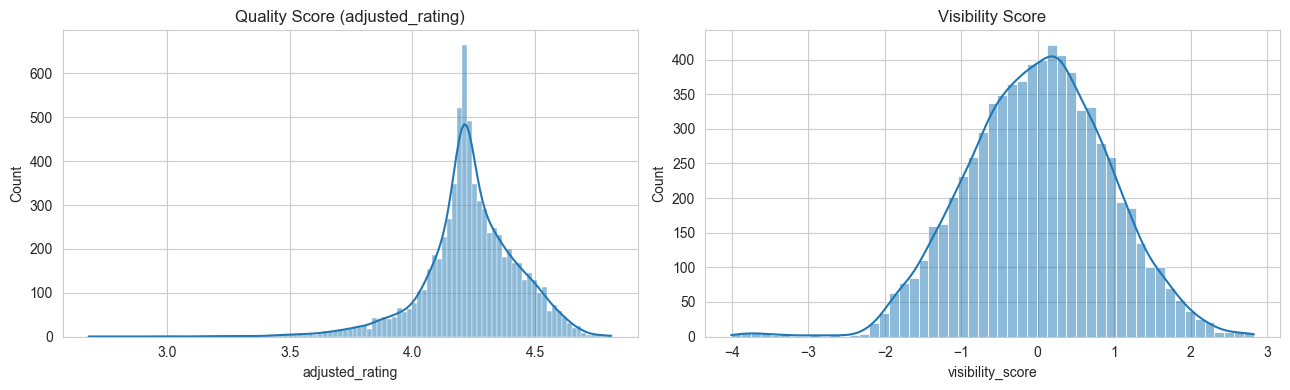

In [7]:
products_clean["log_reviews"] = np.log1p(products_clean["reviews"])
products_clean["log_loves"] = np.log1p(products_clean["loves_count"])
products_clean["log_price"] = np.log1p(products_clean["price_usd"])

visibility_scaler = StandardScaler()
visibility_z = visibility_scaler.fit_transform(products_clean[["log_reviews", "log_loves"]])
products_clean["visibility_score"] = visibility_z.mean(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.histplot(products_clean["adjusted_rating"], kde=True, ax=axes[0])
axes[0].set_title("Quality Score (adjusted_rating)")
sns.histplot(products_clean["visibility_score"], kde=True, ax=axes[1])
axes[1].set_title("Visibility Score")
plt.tight_layout()
plt.show()